In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib

In [2]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("data/mobile_price.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
# ==========================================
# Basic Exploration
# ==========================================

print("Shape of Dataset")
print(df.shape)

print("\nFirst Five Rows")
display(df.head())

print("\nDataset Information")
df.info()

print("\nStatistical Summary")
display(df.describe())

Shape of Dataset
(2000, 21)

First Five Rows


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1



Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [4]:
# ==========================================
# Missing Values
# ==========================================

print(df.isnull().sum())

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


In [5]:
# ==========================================
# Duplicate Rows
# ==========================================

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


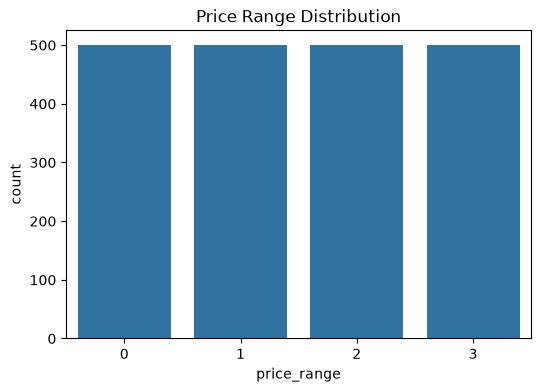

In [6]:
# ==========================================
# Target Variable Distribution
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(x="price_range", data=df)

plt.title("Price Range Distribution")

plt.show()

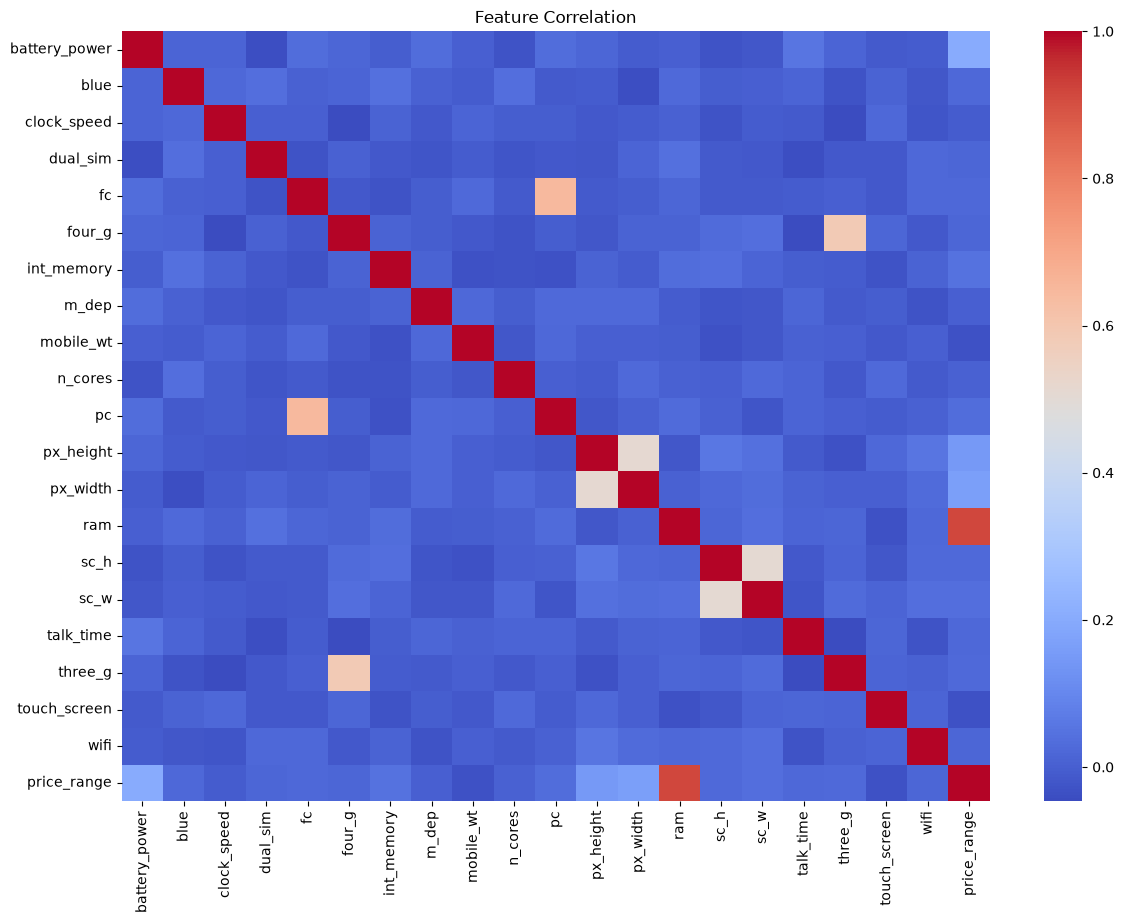

In [7]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(14,10))

sns.heatmap(df.corr(),
            cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()

In [8]:
# ==========================================
# Features and Target
# ==========================================

X = df.drop("price_range", axis=1)

y = df["price_range"]

print(X.shape)
print(y.shape)

(2000, 20)
(2000,)


In [9]:
# ==========================================
# Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1600, 20)
(400, 20)


In [10]:
# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [11]:
# ==========================================
# Train Models
# ==========================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "KNN":
        KNeighborsClassifier(),

    "Naive Bayes":
        GaussianNB(),

    "Random Forest":
        RandomForestClassifier(random_state=42)

}

trained_models = {}

for name, model in models.items():

    if name in ["Logistic Regression", "KNN"]:

        model.fit(X_train_scaled, y_train)

    else:

        model.fit(X_train, y_train)

    trained_models[name] = model

print("Training Completed")

Training Completed


In [12]:
# ==========================================
# Model Evaluation
# ==========================================

results = []

for name, model in trained_models.items():

    if name in ["Logistic Regression", "KNN"]:

        y_pred = model.predict(X_test_scaled)

        y_prob = model.predict_proba(X_test_scaled)

    else:

        y_pred = model.predict(X_test)

        y_prob = model.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    auc = roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr"
    )

    results.append([

        name,
        accuracy,
        precision,
        recall,
        f1,
        mcc,
        auc

    ])

results_df = pd.DataFrame(

    results,

    columns=[

        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "MCC",
        "AUC"

    ]

)

display(results_df.sort_values(
    by="Accuracy",
    ascending=False
))

,Model,Accuracy,Precision,Recall,F1 Score,MCC,AUC
0,Logistic Regression,0.965,0.965045,0.965,0.964986,0.953357,0.998667
4,Random Forest,0.880,0.879938,0.880,0.879947,0.840014,0.977383
1,Decision Tree,0.830,0.831883,0.830,0.830168,0.773811,0.886667
3,Naive Bayes,0.810,0.811326,0.810,0.810458,0.746804,0.950567
2,KNN,0.500,0.521130,0.500,0.505355,0.334993,0.769750


In [13]:
best_model = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

display(best_model)

,Model,Accuracy,Precision,Recall,F1 Score,MCC,AUC
0,Logistic Regression,0.965,0.965045,0.965,0.964986,0.953357,0.998667
4,Random Forest,0.880,0.879938,0.880,0.879947,0.840014,0.977383
1,Decision Tree,0.830,0.831883,0.830,0.830168,0.773811,0.886667
3,Naive Bayes,0.810,0.811326,0.810,0.810458,0.746804,0.950567
2,KNN,0.500,0.521130,0.500,0.505355,0.334993,0.769750


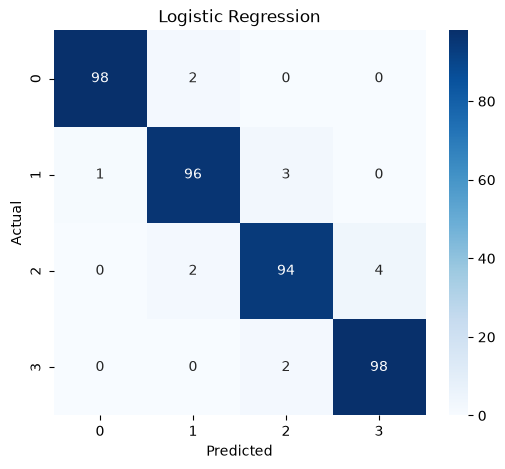

In [14]:
# ==========================================
# Confusion Matrix
# ==========================================

best_name = best_model.iloc[0]["Model"]

model = trained_models[best_name]

if best_name in ["Logistic Regression","KNN"]:

    y_pred = model.predict(X_test_scaled)

else:

    y_pred = model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(best_name)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [15]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.96      0.96      0.96       100
           2       0.95      0.94      0.94       100
           3       0.96      0.98      0.97       100

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.97      0.96      0.96       400



In [16]:
# ==========================================
# Save Models
# ==========================================

joblib.dump(
    trained_models["Logistic Regression"],
    "models/logistic_regression.pkl"
)

joblib.dump(
    trained_models["Decision Tree"],
    "models/decision_tree.pkl"
)

joblib.dump(
    trained_models["KNN"],
    "models/knn.pkl"
)

joblib.dump(
    trained_models["Naive Bayes"],
    "models/naive_bayes.pkl"
)

joblib.dump(
    trained_models["Random Forest"],
    "models/random_forest.pkl"
)

joblib.dump(
    scaler,
    "models/scaler.pkl"
)

print("All models saved successfully.")

All models saved successfully.
